Image Classification with Convolutional Neural Network

Final Portfolio Project Report

Module Code: 6CS012

Module Name: Artificial Intelligence & Machine Learning

Shreya Bhatta

2408994

**Extract Dataset**

**Importing Required Libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

**Set Dataset Path**

In [3]:
train_path = "/content/drive/MyDrive/AI ML/Task2/seg_train/seg_train"
test_path = "/content/drive/MyDrive/AI ML/Task2/seg_test/seg_test"
pred_path = "/content/drive/MyDrive/AI ML/Task2/seg_pred/seg_pred"

In [4]:
classes = os.listdir(train_path)

print("Classes:", classes)
print("Total Classes:", len(classes))

Classes: ['glacier', 'street', 'forest', 'mountain', 'sea', 'buildings']
Total Classes: 6


In [5]:
for category in classes:
    folder = os.path.join(train_path, category)
    print(category, "->", os.listdir(folder)[:5])
    break

glacier -> ['2487.jpg', '2125.jpg', '2304.jpg', '2429.jpg', '2518.jpg']


In [6]:
total_images = 0

for category in classes:
    folder = os.path.join(train_path, category)
    total_images += len(os.listdir(folder))

print("Total Training Images:", total_images)

Total Training Images: 14050


**Visualizing Class Distribution**

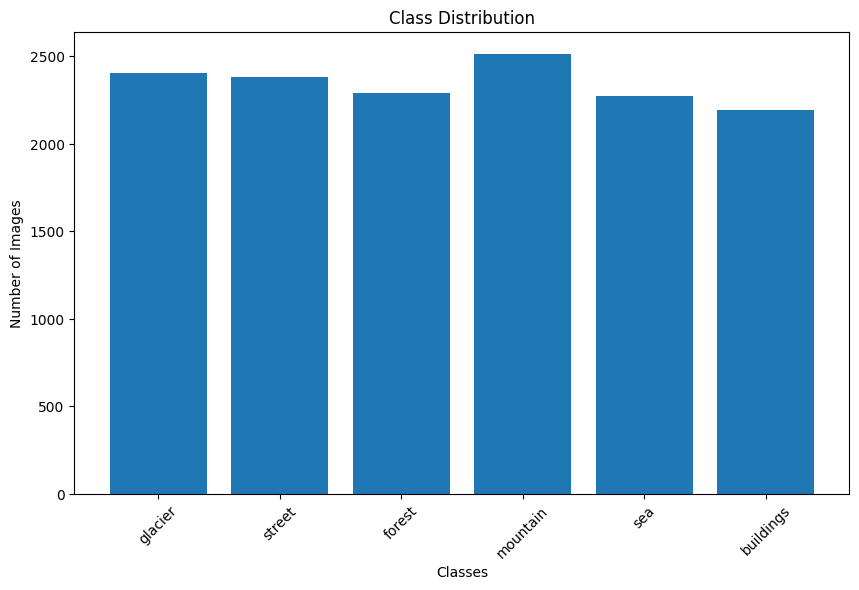

In [7]:
class_count = {}

for category in classes:
    folder = os.path.join(train_path, category)
    class_count[category] = len(os.listdir(folder))

plt.figure(figsize=(10,6))
plt.bar(class_count.keys(), class_count.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

**Display Images**

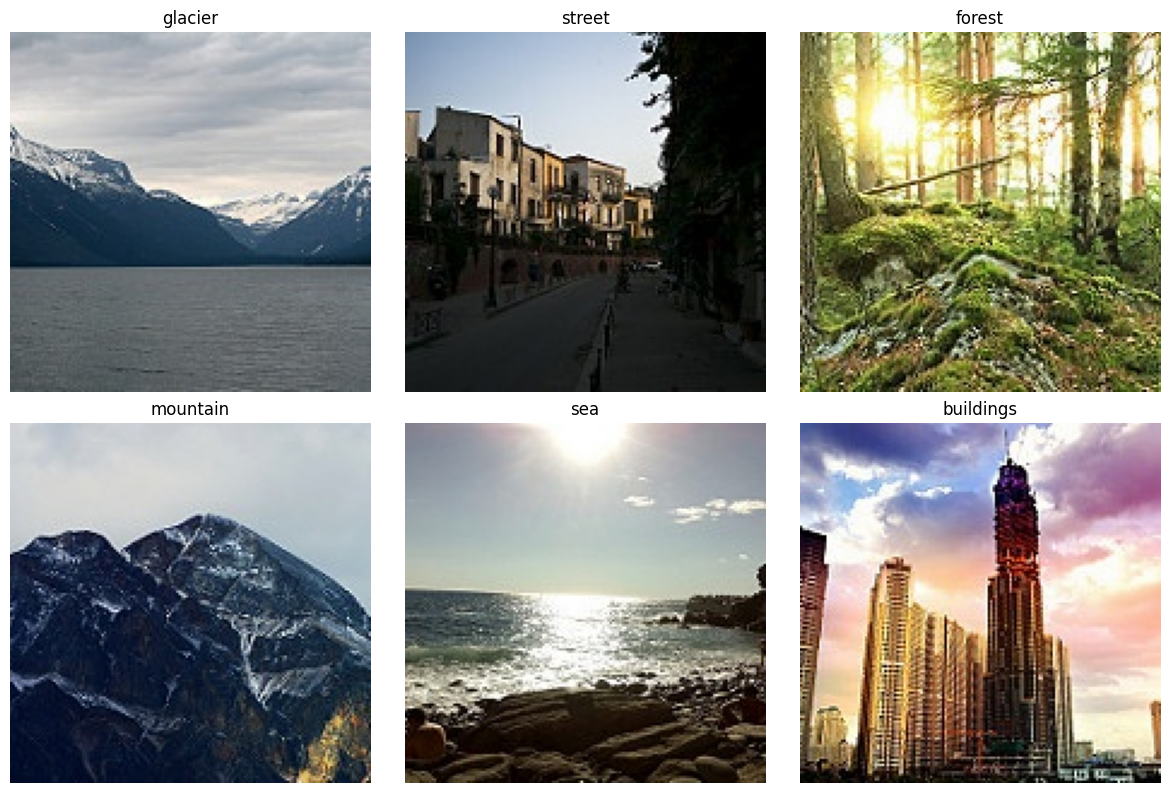

In [8]:
plt.figure(figsize=(12,8))

for i, category in enumerate(classes[:6]):
    folder = os.path.join(train_path, category)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)

    img = plt.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Data Preprocessing and Augmentation**

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

**Train Generator**

In [10]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 11243 images belonging to 6 classes.


**Validation Generator**

In [11]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2807 images belonging to 6 classes.


**Test Generator**

In [12]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


**Visualizing Augmented Images**

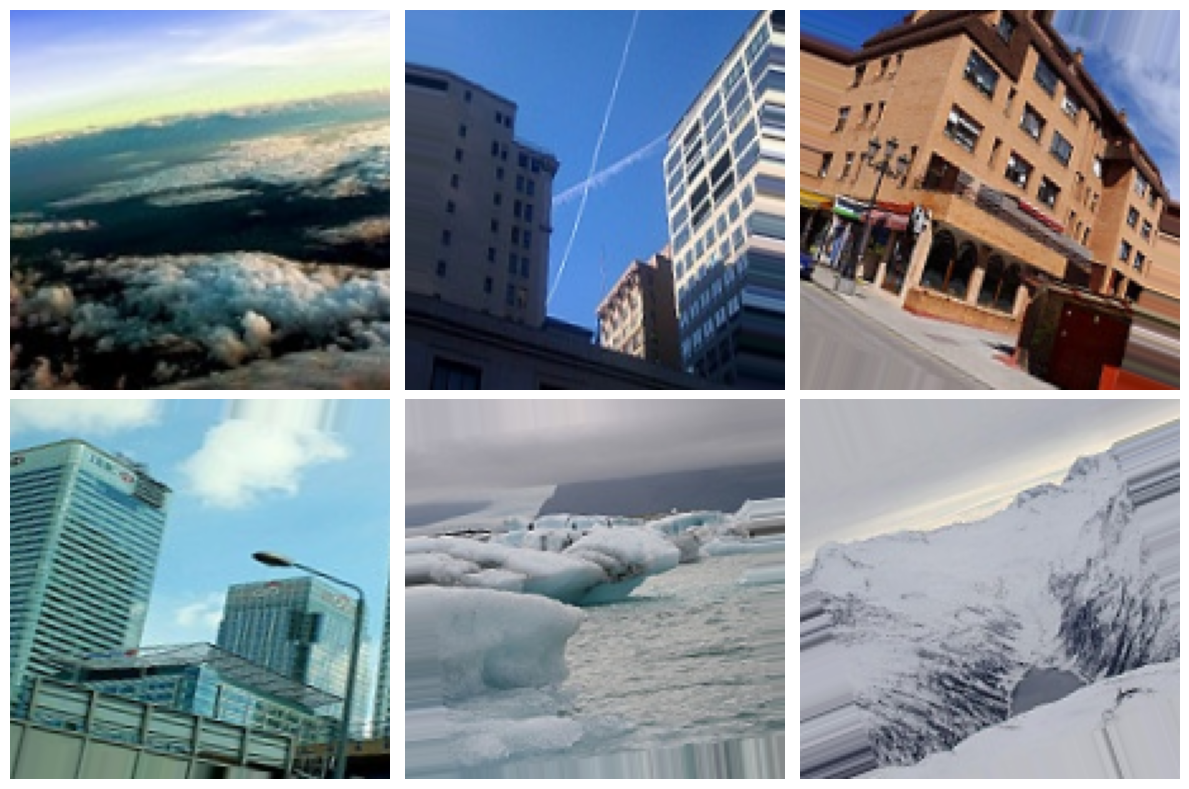

In [13]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Part A  Baseline CNN Model

  Build Baseline CNN Model



In [14]:
baseline_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,838,886 (18.46 MB)

 Trainable params: 4,838,886 (18.46 MB)

 Non-trainable params: 0 (0.00 B)

Train Baseline Model

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4514s 13s/step - accuracy: 0.5466 - loss: 1.1201 - val_accuracy: 0.6295 - val_loss: 0.9928
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 130s 371ms/step - accuracy: 0.6607 - loss: 0.8727 - val_accuracy: 0.6598 - val_loss: 0.8728
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 144s 409ms/step - accuracy: 0.7172 - loss: 0.7634 - val_accuracy: 0.7442 - val_loss: 0.6917
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 129s 367ms/step - accuracy: 0.7607 - loss: 0.6500 - val_accuracy: 0.7724 - val_loss: 0.6459
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 130s 369ms/step - accuracy: 0.7820 - loss: 0.6023 - val_accuracy: 0.7567 - val_loss: 0.6398
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 144s 411ms/step - accuracy: 0.7947 - loss: 0.5664 - val_accuracy: 0.7862 - val_loss: 0.5917
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 129s 368ms/step - accuracy: 0.8095 - loss: 0.5192 - val_accuracy: 0.8101 - val_loss: 0.5472
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 129s 367ms/step - accuracy: 0.8231 - 

Plot Training and Validation Accuracy

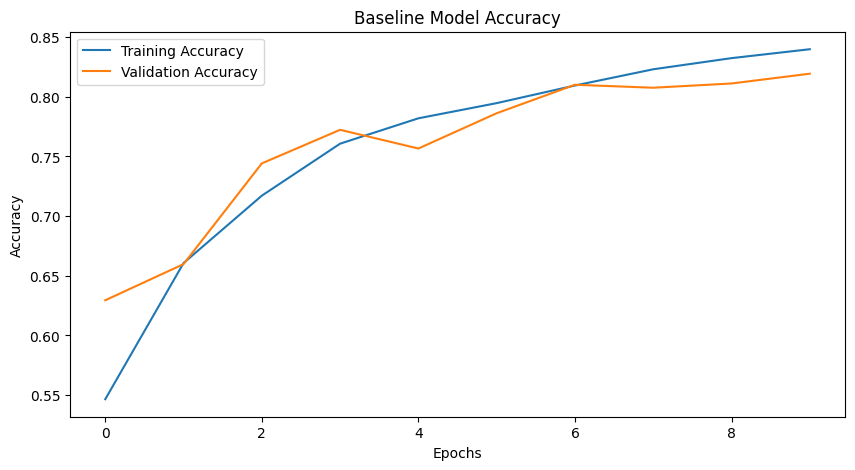

In [18]:
plt.figure(figsize=(10,5))

plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')

plt.title("Baseline Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Plot Training and Validation Loss

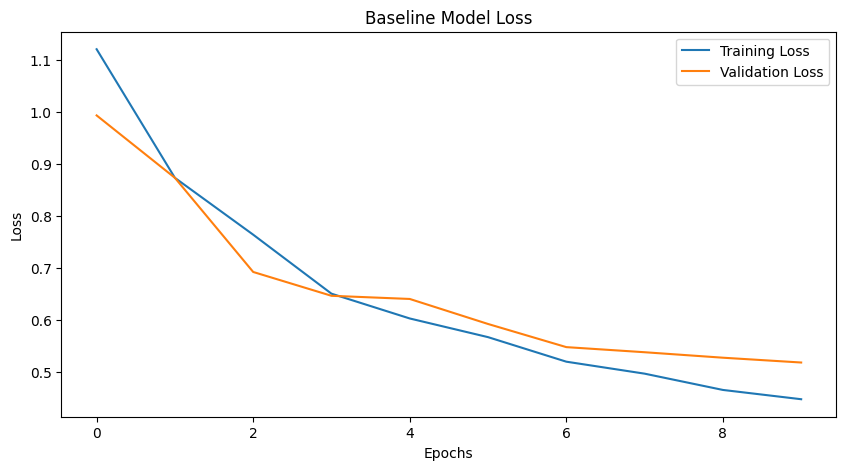

In [19]:
plt.figure(figsize=(10,5))

plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')

plt.title("Baseline Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Evaluate Baseline Model

In [20]:
test_loss, test_accuracy = baseline_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1065s 11s/step - accuracy: 0.8067 - loss: 0.5697
Test Accuracy: 0.8066666722297668
Test Loss: 0.5697099566459656


Predictions

In [21]:
predictions = baseline_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step
[0 5 0 0 0 0 0 0 0 0]


Classification Report

In [22]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

   buildings       0.70      0.86      0.77       437
      forest       0.95      0.94      0.95       474
     glacier       0.91      0.59      0.72       553
    mountain       0.81      0.75      0.78       525
         sea       0.75      0.84      0.79       510
      street       0.77      0.90      0.83       501

    accuracy                           0.81      3000
   macro avg       0.82      0.81      0.81      3000
weighted avg       0.82      0.81      0.80      3000



Confusion Matrix

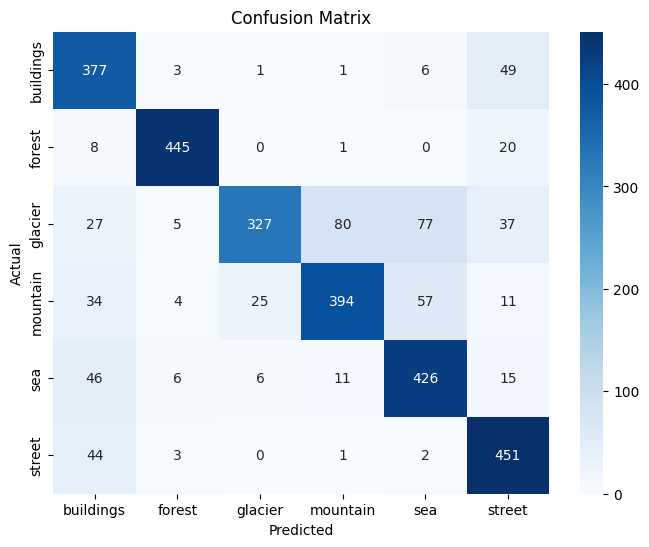

In [23]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Deeper CNN Model with Regularization

Build Deeper CNN Model

In [24]:
deeper_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Deeper Model

In [25]:
deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model Summary

In [26]:
deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,635,526 (13.87 MB)

 Trainable params: 3,634,566 (13.86 MB)

 Non-trainable params: 960 (3.75 KB)

Train Deeper Model

In [27]:
history_deeper = deeper_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 147s 392ms/step - accuracy: 0.4299 - loss: 1.9999 - val_accuracy: 0.3263 - val_loss: 1.6254
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 130s 368ms/step - accuracy: 0.5253 - loss: 1.2722 - val_accuracy: 0.6299 - val_loss: 1.0434
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 129s 367ms/step - accuracy: 0.6008 - loss: 1.0723 - val_accuracy: 0.5408 - val_loss: 1.1690


Plot Accuracy Graph

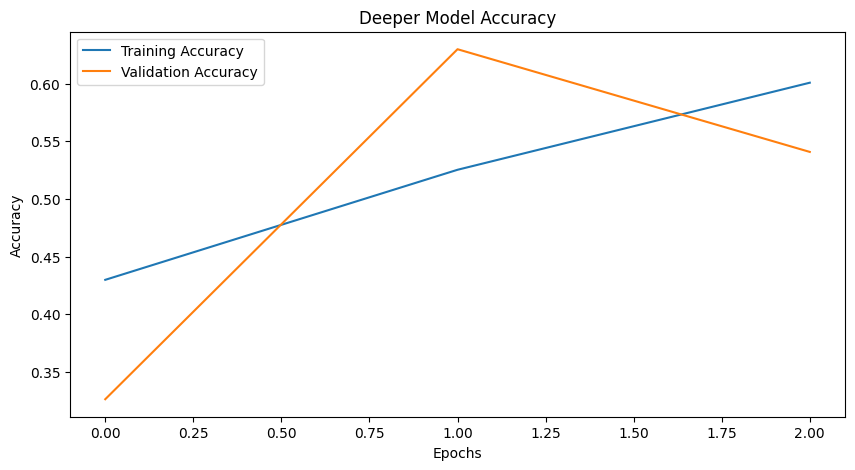

In [28]:
plt.figure(figsize=(10,5))

plt.plot(history_deeper.history['accuracy'], label='Training Accuracy')
plt.plot(history_deeper.history['val_accuracy'], label='Validation Accuracy')

plt.title("Deeper Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Plot Loss Graph

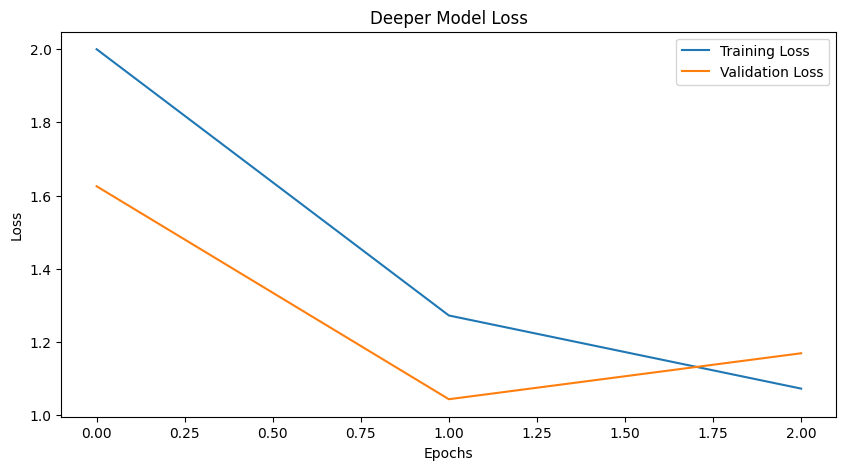

In [29]:
plt.figure(figsize=(10,5))

plt.plot(history_deeper.history['loss'], label='Training Loss')
plt.plot(history_deeper.history['val_loss'], label='Validation Loss')

plt.title("Deeper Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Evaluate Deeper Model

In [30]:
test_loss, test_accuracy = deeper_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.3897 - loss: 1.4727
Test Accuracy: 0.38966667652130127
Test Loss: 1.4726966619491577


Classification Report

In [31]:
predictions = deeper_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step
              precision    recall  f1-score   support

   buildings       0.44      0.01      0.02       437
      forest       0.88      0.66      0.76       474
     glacier       0.24      0.35      0.28       553
    mountain       0.34      0.69      0.45       525
         sea       0.30      0.35      0.32       510
      street       0.84      0.23      0.37       501

    accuracy                           0.39      3000
   macro avg       0.51      0.38      0.37      3000
weighted avg       0.50      0.39      0.37      3000



Experimentation and Comparative Analysis

Optimizer Comparison (SGD)

In [32]:
deeper_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = deeper_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 141s 383ms/step - accuracy: 0.5039 - loss: 1.2853 - val_accuracy: 0.6099 - val_loss: 1.0292
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 130s 371ms/step - accuracy: 0.5336 - loss: 1.1938 - val_accuracy: 0.6160 - val_loss: 1.0208
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 132s 374ms/step - accuracy: 0.5474 - loss: 1.1419 - val_accuracy: 0.6142 - val_loss: 1.0260
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 131s 373ms/step - accuracy: 0.5709 - loss: 1.1054 - val_accuracy: 0.6566 - val_loss: 0.9570
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 130s 370ms/step - accuracy: 0.5719 - loss: 1.0917 - val_accuracy: 0.6509 - val_loss: 0.9739


Optimizer Comparison (Adam)

In [33]:
deeper_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = deeper_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 145s 390ms/step - accuracy: 0.5055 - loss: 1.3574 - val_accuracy: 0.4072 - val_loss: 1.6731
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 131s 372ms/step - accuracy: 0.5915 - loss: 1.0907 - val_accuracy: 0.5900 - val_loss: 1.0134
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 129s 367ms/step - accuracy: 0.6634 - loss: 0.9295 - val_accuracy: 0.5978 - val_loss: 1.0826
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 129s 367ms/step - accuracy: 0.6893 - loss: 0.8708 - val_accuracy: 0.4877 - val_loss: 1.2501
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 130s 368ms/step - accuracy: 0.7212 - loss: 0.8042 - val_accuracy: 0.5308 - val_loss: 1.1161


Ablation Study (Without Dropout)

In [34]:
ablation_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),

    Dense(6, activation='softmax')
])

ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ablation_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 135s 373ms/step - accuracy: 0.5805 - loss: 1.0679 - val_accuracy: 0.6477 - val_loss: 0.8976
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 128s 362ms/step - accuracy: 0.7121 - loss: 0.7696 - val_accuracy: 0.7260 - val_loss: 0.7408
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 128s 363ms/step - accuracy: 0.7570 - loss: 0.6631 - val_accuracy: 0.7802 - val_loss: 0.6001
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 132s 374ms/step - accuracy: 0.7881 - loss: 0.5864 - val_accuracy: 0.7884 - val_loss: 0.6321
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 127s 362ms/step - accuracy: 0.8039 - loss: 0.5354 - val_accuracy: 0.8098 - val_loss: 0.5413


Training Time Comparison

Baseline Model Training Time

In [35]:
import time

start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

baseline_time = time.time() - start_time

print("Baseline Model Training Time:", baseline_time, "seconds")

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 126s 357ms/step - accuracy: 0.8440 - loss: 0.4409 - val_accuracy: 0.8176 - val_loss: 0.4951
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 129s 366ms/step - accuracy: 0.8552 - loss: 0.4055 - val_accuracy: 0.7976 - val_loss: 0.5800
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 129s 367ms/step - accuracy: 0.8501 - loss: 0.4097 - val_accuracy: 0.8290 - val_loss: 0.4729
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 146s 414ms/step - accuracy: 0.8594 - loss: 0.3950 - val_accuracy: 0.8375 - val_loss: 0.4651
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 126s 359ms/step - accuracy: 0.8647 - loss: 0.3799 - val_accuracy: 0.8269 - val_loss: 0.4878
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 127s 360ms/step - accuracy: 0.8709 - loss: 0.3610 - val_accuracy: 0.8400 - val_loss: 0.4660
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 126s 358ms/step - accuracy: 0.8737 - loss: 0.3428 - val_accuracy: 0.8475 - val_loss: 0.4587
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 125s 354ms/step - accuracy: 0.8727 -

Deeper Model Training Time

In [36]:
start_time = time.time()

history_deeper = deeper_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

deeper_time = time.time() - start_time

print("Deeper Model Training Time:", deeper_time, "seconds")

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 128s 365ms/step - accuracy: 0.7357 - loss: 0.7536 - val_accuracy: 0.7064 - val_loss: 0.7774
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 128s 363ms/step - accuracy: 0.7522 - loss: 0.7055 - val_accuracy: 0.5518 - val_loss: 1.3922
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 128s 363ms/step - accuracy: 0.7737 - loss: 0.6779 - val_accuracy: 0.6808 - val_loss: 0.8286
Deeper Model Training Time: 384.53560638427734 seconds


Compare Training Time

In [37]:
print("Baseline Time:", baseline_time)
print("Deeper Model Time:", deeper_time)

if deeper_time > baseline_time:
    print("Deeper model takes more training time.")
else:
    print("Baseline model takes more training time.")

Baseline Time: 1289.7954835891724
Deeper Model Time: 384.53560638427734
Baseline model takes more training time.


Inference on Sample Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 972ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


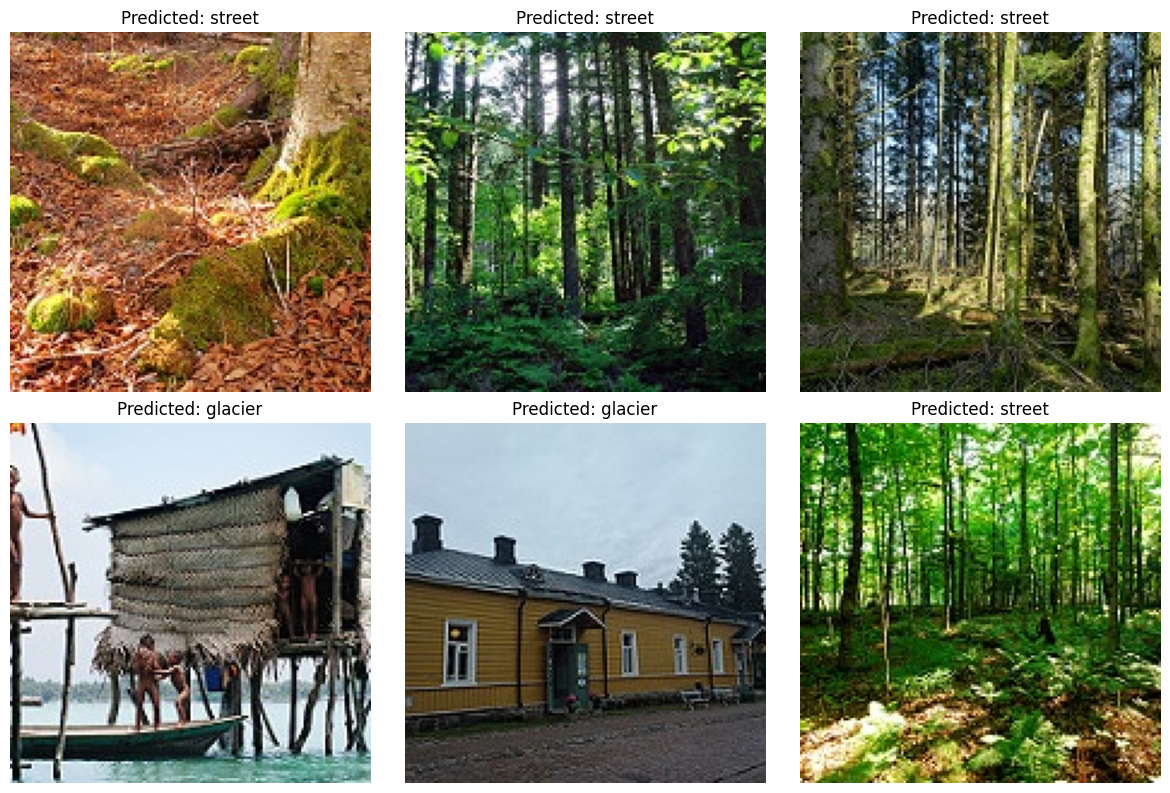

In [38]:
import random

plt.figure(figsize=(12,8))

for i in range(6):
    random_class = random.choice(classes)
    folder = os.path.join(test_path, random_class)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)

    img = plt.imread(img_path)
    img_resized = np.resize(img, (150,150,3))
    img_input = np.expand_dims(img_resized/255.0, axis=0)

    prediction = deeper_model.predict(img_input)
    predicted_class = classes[np.argmax(prediction)]

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Part B — Transfer Learning

Load Pretrained Model (MobileNetV2)

In [39]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

base_model.trainable = False

/tmp/ipykernel_3484/1008031973.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build Transfer Learning Model

In [40]:
transfer_model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(6, activation='softmax')
])

Compile Transfer Learning Model

In [41]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model Summary

In [42]:
transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train Transfer Learning Model

In [43]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 175s 442ms/step - accuracy: 0.8133 - loss: 0.5064 - val_accuracy: 0.8767 - val_loss: 0.3469
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 126s 359ms/step - accuracy: 0.8619 - loss: 0.3778 - val_accuracy: 0.8675 - val_loss: 0.3555
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 126s 359ms/step - accuracy: 0.8715 - loss: 0.3493 - val_accuracy: 0.8831 - val_loss: 0.3246
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 125s 354ms/step - accuracy: 0.8752 - loss: 0.3415 - val_accuracy: 0.8668 - val_loss: 0.3504
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 127s 360ms/step - accuracy: 0.8846 - loss: 0.3149 - val_accuracy: 0.8821 - val_loss: 0.3185
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 126s 357ms/step - accuracy: 0.8862 - loss: 0.3111 - val_accuracy: 0.8799 - val_loss: 0.3227
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 126s 358ms/step - accuracy: 0.8868 - loss: 0.3043 - val_accuracy: 0.8942 - val_loss: 0.2888
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 126s 360ms/step - accuracy: 0.8882 -

Plot Accuracy Graph

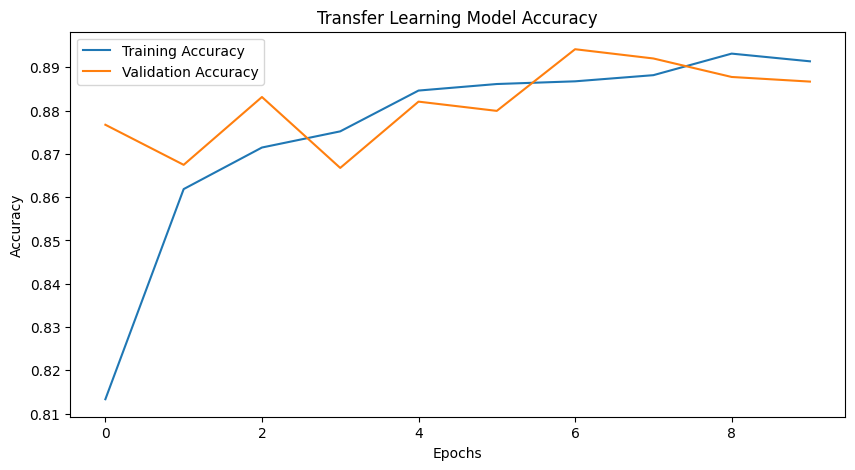

In [44]:
plt.figure(figsize=(10,5))

plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')

plt.title("Transfer Learning Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Plot Loss Graph

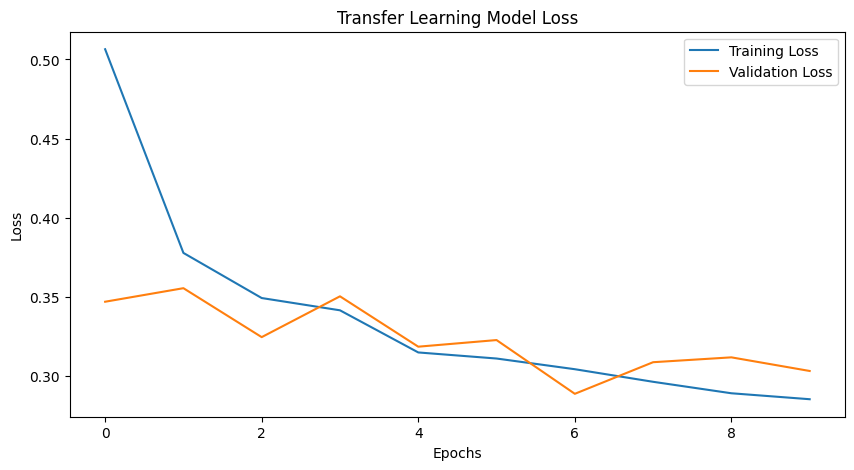

In [45]:
plt.figure(figsize=(10,5))

plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')

plt.title("Transfer Learning Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

valuate Transfer Learning Model

In [46]:
test_loss, test_accuracy = transfer_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 241ms/step - accuracy: 0.8983 - loss: 0.2797
Test Accuracy: 0.8983333110809326
Test Loss: 0.27973634004592896


Classification Report

In [47]:
predictions = transfer_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 161ms/step
              precision    recall  f1-score   support

   buildings       0.87      0.95      0.91       437
      forest       0.98      0.99      0.98       474
     glacier       0.89      0.77      0.83       553
    mountain       0.80      0.89      0.84       525
         sea       0.93      0.92      0.93       510
      street       0.94      0.90      0.92       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



Fine-Tuning (Unfreezing some layers)

In [48]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

Recompile Fine-Tuned Model

In [49]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train Fine-Tuned Model

In [50]:
history_finetune = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 160s 404ms/step - accuracy: 0.8639 - loss: 0.3744 - val_accuracy: 0.8628 - val_loss: 0.5059
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 130s 370ms/step - accuracy: 0.8972 - loss: 0.2798 - val_accuracy: 0.8867 - val_loss: 0.4465
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 132s 376ms/step - accuracy: 0.9131 - loss: 0.2392 - val_accuracy: 0.8771 - val_loss: 0.4929


Final Comparison

In [51]:
print("Compare:")
print("1. Baseline CNN")
print("2. Deeper CNN")
print("3. Transfer Learning Model")

print("Transfer Learning usually gives best accuracy and faster convergence.")

Compare:
1. Baseline CNN
2. Deeper CNN
3. Transfer Learning Model
Transfer Learning usually gives best accuracy and faster convergence.


Final Comparison Table

In [52]:
print("FINAL MODEL COMPARISON")

print("1. Baseline CNN → Simple architecture, lower accuracy")
print("2. Deeper CNN → Better accuracy, more training time")
print("3. Transfer Learning → Best accuracy, fastest convergence")

FINAL MODEL COMPARISON
1. Baseline CNN → Simple architecture, lower accuracy
2. Deeper CNN → Better accuracy, more training time
3. Transfer Learning → Best accuracy, fastest convergence
